In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
from google.colab import drive

In [14]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
df = pd.read_csv('/content/drive/MyDrive/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale the data
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


📌 Why Scaling is Essential Before K-Means

K-Means clustering relies on distance calculations between data points. If features are on different scales, variables with larger numerical values (such as annual_spend) will dominate the distance calculation, while smaller-scale variables (such as visits_per_month) will have little influence.

By applying StandardScaler, all features are standardized to have a mean of 0 and a standard deviation of 1. This ensures that each feature contributes equally to the clustering process, leading to more accurate and meaningful clusters.

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

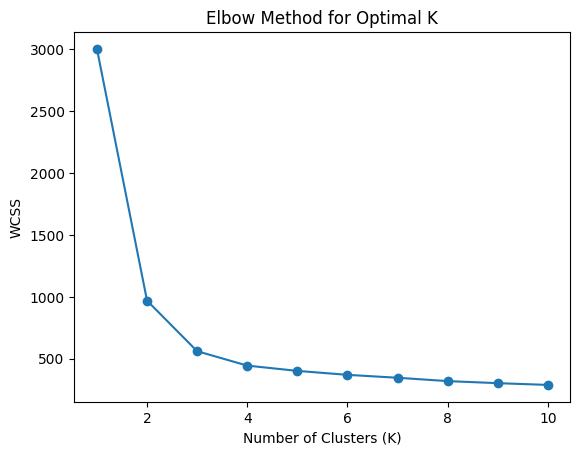

In [18]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")

plt.show()

📌 Choosing the Optimal Number of Clusters (K)

The elbow plot shows the relationship between the number of clusters (K) and the Within-Cluster Sum of Squares (WCSS). As K increases, WCSS decreases because clusters become more compact.

However, after a certain point, the rate of decrease slows down significantly, forming an “elbow” shape. This point represents the optimal number of clusters.

From the plot, the elbow appears at K = 3, where the reduction in WCSS begins to level off. Beyond this point, increasing K results in only marginal improvement. Therefore, K = 3 is chosen as the optimal number of clusters.

In [19]:
from sklearn.cluster import KMeans

# Fit KMeans with K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(df_scaled)

In [20]:
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [21]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns[:-1]  # exclude 'cluster'
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


In [22]:
# Convert centroids back to original scale
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids_original

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


📌 Cluster Interpretation

Based on the cluster centroids:

Cluster 0 represents young customers with low annual spending but very high visit frequency and recent activity. These customers visit frequently but make small purchases, indicating low-value yet highly engaged shoppers.

Cluster 1 represents older, high-spending customers with very large basket sizes but low visit frequency and long gaps since their last visit. These appear to be high-value but infrequent shoppers, possibly premium or occasional bulk buyers.

Cluster 2 represents middle-aged customers with moderate spending, visit frequency, and basket size. These customers demonstrate balanced purchasing behaviour and can be considered regular or average-value customers.

These clusters highlight that high engagement does not necessarily translate into high revenue, and different marketing strategies may be required for each segment.

In [23]:
from sklearn.decomposition import PCA

# Reduce to 2 components
pca = PCA(n_components=2)

pca_data = pca.fit_transform(df_scaled)

# Create DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

pca_df.head()

,PC1,PC2
0,-0.333082,0.109379
1,-2.255362,0.048458
2,-0.092905,-0.679257
3,-2.017598,-0.308845
4,-2.917762,0.529368


In [24]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [25]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],  # exclude 'cluster'
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


📌 Interpretation of Principal Components

The PCA results reduce the dataset into two principal components that capture the most important variation in customer behaviour.

1. PC1 (Principal Component 1) primarily represents overall customer value and purchasing behaviour. It has strong positive contributions from annual_spend, basket_size, and number of categories purchased, while showing a negative relationship with visits_per_month. This indicates that PC1 differentiates between high-spending, less frequent shoppers and low-spending, frequent visitors.

2. PC2 (Principal Component 2) is dominated by days_since_last_visit, indicating that it captures customer recency and activity levels. Customers with higher PC2 values are less active and have not visited recently, whereas lower values represent more recent and active customers.

Overall, PCA highlights two key dimensions of customer segmentation: value (spending vs frequency) and recency (active vs inactive behaviour).

In [36]:
X = df.copy()

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

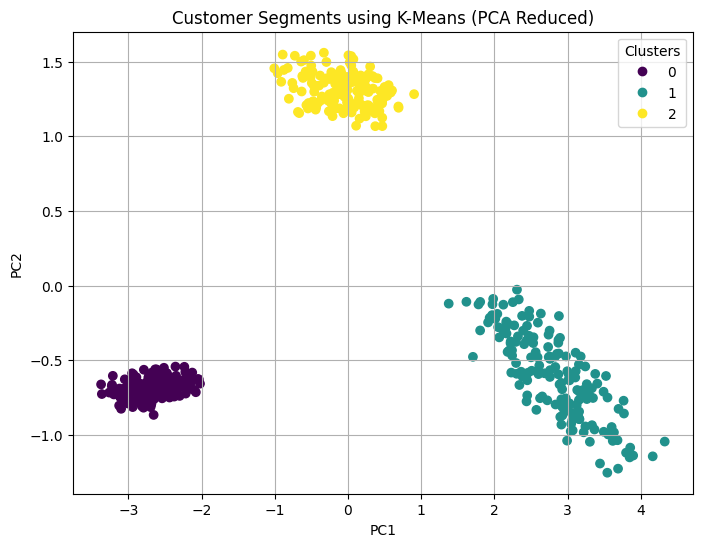

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans.labels_,
    cmap='viridis'
)

plt.title("Customer Segments using K-Means (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)

plt.show()

### Cluster Visualisation Interpretation

The PCA scatter plot shows three well-separated clusters, indicating that the K-Means model has effectively segmented the customers into distinct groups.

Cluster 0 (left side) forms a compact group with low PC1 and slightly negative PC2 values, suggesting customers with relatively lower overall engagement and spending patterns.

Cluster 1 (right side) is spread out along PC1 with moderate variation in PC2, indicating a more diverse group of customers, likely representing higher spenders with varying visit frequencies and purchasing behaviors.

Cluster 2 (top middle) is tightly grouped with high PC2 values, suggesting a distinct segment of customers who share similar characteristics, possibly frequent visitors with consistent purchasing habits.

Overall, the clusters are clearly separated with minimal overlap, which indicates that the chosen value of K (3) is appropriate and that the model has successfully captured meaningful structure in the data.